<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Experiments/Experiments_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
DATA_PATH = "HTML_All_Features.csv"
LABEL_COL = "label"

In [ ]:
df=pd.read_csv(DATA_PATH)
print("Original shape:",df.shape)
display(df.head())
print(df[LABEL_COL].value_counts())

Original shape: (19997, 42)


,file_size,line_count,entropy,script_entropy,tag_count,unique_tag_count,script_count,form_count,iframe_count,hidden_iframe_count,...,object_tag_count,url_digit_count,url_punct_char_count,url_avg_length,url_avg_subdomain_count,hostname_digit_ratio_avg,min_link_length,max_link_length,file_path,label
0,2014,49,5.252908,4.802471,20,12,1,1,0,0,...,0,0,8,15.750000,0.000000,0.000000,14,18,/content/drive/MyDrive/UNB/Mastercard project/...,1
1,177022,3970,4.720787,4.634752,875,13,5,0,0,0,...,0,1139,1033,13.724706,0.061176,0.000000,7,82,/content/drive/MyDrive/UNB/Mastercard project/...,0
2,191188,3088,5.149307,5.371950,1107,33,51,3,0,0,...,0,845,3064,55.930514,1.223565,0.000697,1,132,/content/drive/MyDrive/UNB/Mastercard project/...,0
3,56968,2319,4.726188,4.431225,886,22,11,1,0,0,...,0,1149,1701,26.518310,0.028169,0.000000,1,68,/content/drive/MyDrive/UNB/Mastercard project/...,0
4,167,6,5.052407,0.000000,4,4,0,0,0,0,...,0,0,0,0.000000,0.000000,0.000000,0,0,/content/drive/MyDrive/UNB/Mastercard project/...,1


label
1    9999
0    9998
Name: count, dtype: int64


In [ ]:
check=pd.DataFrame({
    "dtype":df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_rate":df.isna().mean(),
    "unique_count":df.nunique(dropna=True)
}).sort_values(["missing_rate", "unique_count"], ascending=[False, True])

display(check)
print("Exact duplicated rows:", df.duplicated().sum())


,dtype,missing_count,missing_rate,unique_count
label,int64,0,0.0,2
hidden_iframe_count,int64,0,0.0,8
object_tag_count,int64,0,0.0,15
iframe_count,int64,0,0.0,17
mailto_link_count,int64,0,0.0,25
eval_in_script_blocks,int64,0,0.0,25
form_count,int64,0,0.0,42
redirect_mechanism_count,int64,0,0.0,53
max_tag_nesting_depth,int64,0,0.0,60
unique_tag_count,int64,0,0.0,73


Exact duplicated rows: 0


In [ ]:
# Detect exactly duplicated feature columns
feature_cols = [c for c in df.columns if c != LABEL_COL]
duplicate_feature_pairs = []

for i, col1 in enumerate(feature_cols):
    for col2 in feature_cols[i + 1:]:
        if df[col1].equals(df[col2]):
            duplicate_feature_pairs.append((col1, col2))

display(pd.DataFrame(duplicate_feature_pairs, columns=["kept_candidate", "duplicate_candidate"]))

# Drop only the second occurrence of each exact duplicate pair.
duplicate_feature_cols_to_drop = sorted({b for _, b in duplicate_feature_pairs})
print("Exact duplicate feature columns to drop:", duplicate_feature_cols_to_drop)

,kept_candidate,duplicate_candidate
0,external_links_count,external_link_count


Exact duplicate feature columns to drop: ['external_link_count']


In [ ]:
#  Fixed train/test split
# The same test set is used for every model and every training-size experiment.
df = df.dropna(subset=["label", "file_path"])
X = df.drop(columns=[LABEL_COL,"file_path"])
y = df[LABEL_COL]

hiX_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", hiX_train.shape, y_train.value_counts().to_dict())
print("Test :", X_test.shape, y_test.value_counts().to_dict())

Train: (13997, 40) {1: 6999, 0: 6998}
Test : (6000, 40) {0: 3000, 1: 3000}


In [ ]:
(hiX_train.isna().sum().sum())
( X_test.isna().sum().sum())
( y_train.isna().sum())
( y_test.isna().sum())

np.int64(0)

In [ ]:
# Calculate missing values by class

missing_by_class = (
    hiX_train
    .assign(label=y_train.values)
    .groupby("label")
    .apply(lambda x: x.drop(columns="label").isna().mean())
    .T
)

missing_by_class["missing_gap"] = (
    missing_by_class.max(axis=1) -
    missing_by_class.min(axis=1)
)

MISSING_GAP_THRESHOLD = 0.20

suspicious_missing_cols = missing_by_class.index[
    missing_by_class["missing_gap"] >= MISSING_GAP_THRESHOLD
].tolist()

print("Suspicious missing features:")
print(suspicious_missing_cols)

Suspicious missing features:
[]


/tmp/ipykernel_1160/576602151.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.drop(columns="label").isna().mean())


In [ ]:
# Define raw feature sets
raw_all_cols = [
    c for c in hiX_train.columns
    if c not in duplicate_feature_cols_to_drop and c != "file_path"
]
raw_safe_cols = [
    c for c in raw_all_cols
    if c not in suspicious_missing_cols
]


print("Raw-Safe features:", len(raw_safe_cols))
print("Raw-All features:", len(raw_all_cols))

Raw-Safe features: 39
Raw-All features: 39


In [ ]:
# Unified feature construction


BASE_UNIFIED_GROUPS = {
    "file_size": ["file_size"],

    "text_size": ["line_count"],

    "embedded_objects": [
        "iframe_count",
        "hidden_iframe_count",
        "object_tag_count"
    ],

    "active_content_score": [
        "script_count",
        "external_js_count",
        "function_count"
    ],

    "active_content_density": [
        "embedded_js_count",
        "eval_in_script_blocks",
        "event_attachment_count",
        "total_script_characters"
    ],

    "external_reference_count": ["external_links_count"],

    "obfuscation_score": [
        "entropy",
        "script_entropy",
        "base64_string_count",
        "hex_encoding_rate"
    ],

    "structural_complexity_score": [
        "tag_count",
        "unique_tag_count",
        "max_tag_nesting_depth"
    ]
}

LOG_TRANSFORM_COLS = {
    "file_size",
    "total_script_characters"
}

BINARY_COLS = set()

In [ ]:
#  Fit/transform unified features
def fit_unified_transformer(X_train, groups):  # learn scale from train set
    state = {}
    for group_name, cols in groups.items():
        numeric_cols = [c for c in cols if c not in BINARY_COLS]
        scaler = None

        if numeric_cols:
            train_num = X_train[numeric_cols].copy().fillna(0)
            for col in numeric_cols:
                if col in LOG_TRANSFORM_COLS:
                    train_num[col] = np.log1p(train_num[col].clip(lower=0))

            scaler = MinMaxScaler()
            scaler.fit(train_num)

        state[group_name] = {
            "columns": cols,
            "numeric_columns": numeric_cols,
            "binary_columns": [c for c in cols if c in BINARY_COLS],
            "scaler": scaler
        }
    return state


def transform_unified(X, state):
    output = pd.DataFrame(index=X.index)

    for group_name, config in state.items():
        components = []

        numeric_cols = config["numeric_columns"]
        if numeric_cols:
            values = X[numeric_cols].copy().fillna(0)
            for col in numeric_cols:
                if col in LOG_TRANSFORM_COLS:
                    values[col] = np.log1p(values[col].clip(lower=0))

            scaled = config["scaler"].transform(values)
            components.append(pd.Series(scaled.mean(axis=1), index=X.index))

        binary_cols = config["binary_columns"]
        if binary_cols:
            binary_score = X[binary_cols].fillna(0).max(axis=1)
            components.append(binary_score)

        output[group_name] = pd.concat(components, axis=1).mean(axis=1)

    return output.replace([np.inf, -np.inf], 0).fillna(0)


unified_state = fit_unified_transformer(
     hiX_train[raw_all_cols],
    BASE_UNIFIED_GROUPS
)

X_train_unified = transform_unified(hiX_train[raw_all_cols], unified_state)
X_test_unified = transform_unified(X_test[raw_all_cols], unified_state)

print("Unified train shape:", X_train_unified.shape)
display(X_train_unified.head())

Unified train shape: (13997, 8)


,file_size,text_size,embedded_objects,active_content_score,active_content_density,external_reference_count,obfuscation_score,structural_complexity_score
9711,0.357055,0.002324,0.000000,0.007855,0.036210,0.000000,0.151886,0.041205
19733,0.510765,0.011745,0.037037,0.031293,0.138509,0.016747,0.361741,0.056410
9171,0.336170,0.002542,0.000000,0.004945,0.117568,0.000284,0.344886,0.028194
5714,0.384920,0.001981,0.000000,0.000000,0.000331,0.000284,0.173840,0.019698
2151,0.390312,0.004086,0.000000,0.002981,0.117969,0.004542,0.346672,0.040489


In [ ]:
# save the Unified features Dataframe
X_train_unified.to_csv("X_train_unified.csv", index=False)
X_test_unified.to_csv("X_test_unified.csv", index=False)

html_unified_features = pd.concat([X_train_unified, X_test_unified], axis=0)
html_unified_features.to_csv("html_unified_features.csv", index=False)

In [ ]:
#  Model definitions
models = {
    "Logistic_L1": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=1.0,
            max_iter=100,
            random_state=RANDOM_STATE
        ))
    ]),
    "RandomForest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=25,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),

     "XGBoost": Pipeline([
        ("model", XGBClassifier(
            n_estimators=25,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])
}

In [ ]:
#  Evaluation helper
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, feature_set):
    fitted = clone(model)
    fitted.fit(X_train, y_train)

    pred = fitted.predict(X_test)

    if hasattr(fitted, "predict_proba"):
        score = fitted.predict_proba(X_test)[:, 1]
    else:
        score = fitted.decision_function(X_test)

    return fitted, {
        "feature_set": feature_set,
        "model": model_name,
        "n_features": X_train.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro",),
        "recall_macro": recall_score(y_test, pred, average="macro"),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "roc_auc": roc_auc_score(y_test, score),
        "pr_auc": average_precision_score(y_test, score)
    }

In [ ]:
hiX_train_clean = hiX_train[raw_safe_cols]
X_test_clean = X_test[raw_safe_cols]
feature_sets = {
    "Raw_All": (
        hiX_train[raw_all_cols],
        X_test[raw_all_cols]
    ),
    "Unified": (
        X_train_unified,
        X_test_unified
    ),
    "Clean": (
        hiX_train_clean,
        X_test_clean
    )
}
comparison_results = []
fitted_models = {}

for feature_set_name, (Xtr, Xte) in feature_sets.items():
    for model_name, model in models.items():
        fitted, result = evaluate_model(
            model, Xtr, y_train, Xte, y_test,
            model_name=model_name,
            feature_set=feature_set_name
        )
        comparison_results.append(result)
        fitted_models[(feature_set_name, model_name)] = fitted

comparison_df = pd.DataFrame(comparison_results).sort_values(
    ["f1_macro", "pr_auc"], ascending=False
)
display(comparison_df)
comparison_df.to_csv("model_comparison_results.csv", index=False)

,feature_set,model,n_features,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,pr_auc
1,Raw_All,RandomForest,39,0.933167,0.933184,0.933167,0.933166,0.982342,0.983906
7,Clean,RandomForest,39,0.933167,0.933184,0.933167,0.933166,0.982342,0.983906
4,Unified,RandomForest,8,0.904167,0.904170,0.904167,0.904166,0.968804,0.972759
2,Raw_All,XGBoost,39,0.879500,0.879593,0.879500,0.879493,0.949664,0.948398
8,Clean,XGBoost,39,0.879500,0.879593,0.879500,0.879493,0.949664,0.948398
5,Unified,XGBoost,8,0.844833,0.845359,0.844833,0.844774,0.915005,0.909411
0,Raw_All,Logistic_L1,39,0.825000,0.829695,0.825000,0.824375,0.884542,0.850967
6,Clean,Logistic_L1,39,0.825000,0.829695,0.825000,0.824375,0.884542,0.850967
3,Unified,Logistic_L1,8,0.777167,0.780336,0.777167,0.776535,0.820272,0.761805


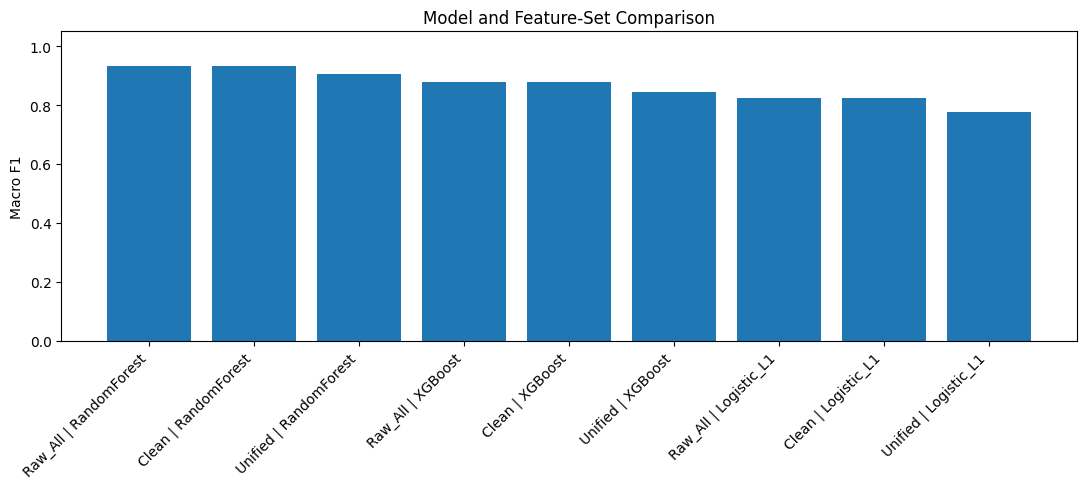

In [ ]:
 # Visual comparison
plot_df = comparison_df.copy()
labels = plot_df["feature_set"] + " | " + plot_df["model"]

plt.figure(figsize=(11, 5))
plt.bar(labels, plot_df["f1_macro"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1")
plt.title("Model and Feature-Set Comparison")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
# L1/LASSO selected features from leakage-reduced raw data
lasso_model = fitted_models[("Raw_All", "Logistic_L1")]
coef = lasso_model.named_steps["model"].coef_[0]

lasso_features = pd.DataFrame({
    "feature": raw_all_cols,
    "coefficient": coef,
    "absolute_coefficient": np.abs(coef)
}).sort_values("absolute_coefficient", ascending=False)

selected_lasso_features = lasso_features.loc[
    lasso_features["absolute_coefficient"] > 1e-8, "feature"
].tolist()

display(lasso_features)
print("Selected by L1:", len(selected_lasso_features))
print(selected_lasso_features)
lasso_features.to_csv("lasso_feature_ranking.csv", index=False)

,feature,coefficient,absolute_coefficient
11,mailto_link_count,-3.032332,3.032332
26,internal_link_count,-1.560472,1.560472
10,external_links_count,-0.949497,0.949497
23,noscript_count,-0.804745,0.804745
19,keywords_to_words_ratio,0.774411,0.774411
5,unique_tag_count,-0.772617,0.772617
14,max_tag_nesting_depth,0.769154,0.769154
27,img_count,0.669448,0.669448
24,embedded_js_count,-0.597781,0.597781
4,tag_count,-0.556396,0.556396


Selected by L1: 38
['mailto_link_count', 'internal_link_count', 'external_links_count', 'noscript_count', 'keywords_to_words_ratio', 'unique_tag_count', 'max_tag_nesting_depth', 'img_count', 'embedded_js_count', 'tag_count', 'max_link_length', 'form_count', 'hidden_iframe_count', 'iframe_count', 'url_avg_length', 'script_entropy', 'event_attachment_count', 'line_count', 'url_punct_char_count', 'script_count', 'base64_string_count', 'entropy', 'suspicious_word_count', 'file_size', 'html_comment_count', 'whitespace_ratio', 'total_script_characters', 'escaped_char_count', 'min_link_length', 'url_digit_count', 'hostname_digit_ratio_avg', 'object_tag_count', 'redirect_mechanism_count', 'url_avg_subdomain_count', 'hex_encoding_rate', 'html_whitespace_ratio', 'eval_in_script_blocks', 'function_count']


In [ ]:
# 17. Evaluate LASSO-selected raw feature subset
if selected_lasso_features:
    selected_results = []

    for model_name, model in models.items():
        _, result = evaluate_model(
            model,
            hiX_train[selected_lasso_features],
            y_train,
            X_test[selected_lasso_features],
            y_test,
            model_name=model_name,
            feature_set="LASSO_Selected_Raw"
        )
        selected_results.append(result)

    selected_df = pd.DataFrame(selected_results)
    display(selected_df)

    comparison_df = pd.concat(
        [comparison_df, selected_df],
        ignore_index=True
    ).sort_values(["f1_macro", "pr_auc"], ascending=False)

    comparison_df.to_csv("model_comparison_results.csv", index=False)

,feature_set,model,n_features,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,pr_auc
0,LASSO_Selected_Raw,Logistic_L1,38,0.825000,0.829695,0.825000,0.824375,0.884536,0.850967
1,LASSO_Selected_Raw,RandomForest,38,0.933333,0.933366,0.933333,0.933332,0.981873,0.983557
2,LASSO_Selected_Raw,XGBoost,38,0.878500,0.878750,0.878500,0.878480,0.949778,0.947969
